In [1]:
import pandas as pd

In [2]:
orders = pd.read_csv('../data/processed/orders_clean.csv', 
                     parse_dates=['order_purchase_timestamp',
                                  'order_approved_at',
                                  'order_delivered_carrier_date',
                                  'order_delivered_customer_date',
                                  'order_estimated_delivery_date'])

order_items = pd.read_csv('../data/processed/order_items_clean.csv',
                          parse_dates=['shipping_limit_date'])

customers = pd.read_csv('../data/processed/customers_clean.csv')
products = pd.read_csv('../data/processed/products_clean.csv')
sellers = pd.read_csv('../data/processed/sellers_clean.csv')
payments = pd.read_csv('../data/processed/payments_clean.csv')
reviews = pd.read_csv('../data/processed/reviews_clean.csv')
geolocation = pd.read_csv('../data/processed/geolocation_clean.csv')
translation = pd.read_csv('../data/processed/translation_clean.csv')

print("All datasets loaded from processed folder")

All datasets loaded from processed folder


In [3]:
deliveries = orders[['order_id','customer_id','order_status','order_purchase_timestamp','order_delivered_customer_date','order_estimated_delivery_date']].copy()
print("Shape:" , deliveries.shape)
display(deliveries.head())

Shape: (99441, 6)


,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26


In [4]:
deliveries = deliveries.merge(customers[['customer_id','customer_state']], on='customer_id', how='left')
print("Shape:" , deliveries.shape)
display(deliveries.head())

Shape: (99441, 7)


,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,SP


In [5]:
reviews_deduped = reviews.groupby('order_id')['review_score'].mean().reset_index()
print("Shape:" , reviews_deduped.shape)
display(reviews_deduped.head())

Shape: (98673, 2)


,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [6]:
deliveries = deliveries.merge(reviews_deduped, on='order_id', how='left')
print("Shape:" , deliveries.shape)
display(deliveries.head())

Shape: (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,BA,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,GO,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,RN,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,SP,5.0


In [7]:
deliveries = deliveries[deliveries['order_status'] == 'delivered'].copy()
print("Shape:" , deliveries.shape)
display(deliveries.head())

Shape: (96478, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,BA,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,GO,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,RN,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,SP,5.0


In [8]:
display(deliveries.columns.tolist())

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_state',
 'review_score']

In [9]:
def get_late_days(row):
    if row['order_delivered_customer_date'] > row['order_estimated_delivery_date']:
        return (row['order_delivered_customer_date'] - row['order_estimated_delivery_date']).days
    else:
        return 0


deliveries['late_days'] = deliveries.apply(get_late_days, axis=1)
print("Shape:" , deliveries.shape)
display(deliveries.head())

Shape: (96478, 9)


,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_state,review_score,late_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,SP,4.0,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,BA,4.0,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,GO,5.0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,RN,5.0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,SP,5.0,0


In [10]:
deliveries['late_delivery_status'] = deliveries['late_days'].apply(lambda x: 'late' if x > 0 else 'on_time')
print("Shape:" , deliveries.shape)
display(deliveries.head())

Shape: (96478, 10)


,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_state,review_score,late_days,late_delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,SP,4.0,0,on_time
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,BA,4.0,0,on_time
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,GO,5.0,0,on_time
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,RN,5.0,0,on_time
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,SP,5.0,0,on_time


In [11]:
delivery_analysis = deliveries.groupby('late_delivery_status')['review_score'].mean().reset_index()
print("Shape:" , delivery_analysis.shape)
display(delivery_analysis)

Shape: (2, 2)


,late_delivery_status,review_score
0,late,2.271823
1,on_time,4.290608


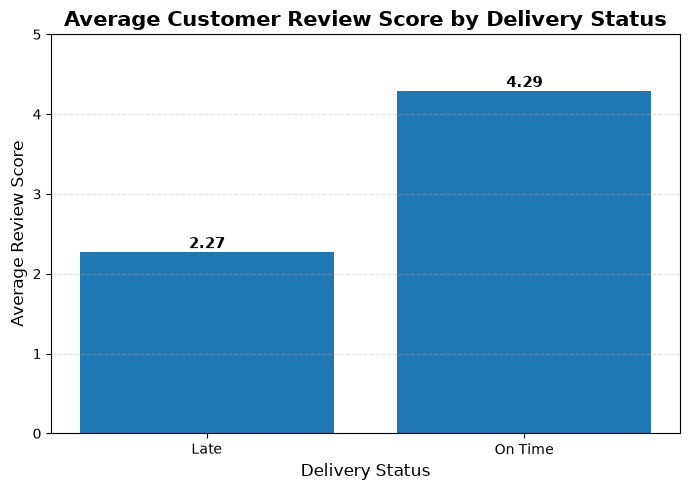

In [12]:
import matplotlib.pyplot as plt

# Create a copy for nicer labels
plot_df = delivery_analysis.copy()

plot_df['late_delivery_status'] = plot_df['late_delivery_status'].replace({
    'on_time': 'On Time',
    'late': 'Late'
})

plt.figure(figsize=(7,5))

bars = plt.bar(
    plot_df['late_delivery_status'],
    plot_df['review_score']
)

plt.title('Average Customer Review Score by Delivery Status',
          fontsize=15,
          weight='bold')

plt.xlabel('Delivery Status', fontsize=12)
plt.ylabel('Average Review Score', fontsize=12)

plt.ylim(0,5)

plt.grid(axis='y',
         linestyle='--',
         alpha=0.4)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f'{height:.2f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [13]:
late_deliveries = deliveries[deliveries['late_delivery_status'] == 'late'].copy()

print("Shape:", late_deliveries.shape)
display(late_deliveries.head())

Shape: (6534, 10)


,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_state,review_score,late_days,late_delivery_status
20,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,delivered,2017-09-18 14:31:30,2017-10-09 22:23:46,2017-09-28,SP,2.0,11,late
25,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,delivered,2018-02-20 23:46:53,2018-03-21 22:03:54,2018-03-12,RJ,2.0,9,late
41,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,delivered,2017-11-24 21:27:48,2017-12-28 18:59:23,2017-12-21,SP,1.0,7,late
57,66e4624ae69e7dc89bd50222b59f581f,684fa6da5134b9e4dab731e00011712d,delivered,2018-03-09 14:50:15,2018-04-03 13:28:46,2018-04-02,SE,1.0,1,late
58,a685d016c8a26f71a0bb67821070e398,911e4c37f5cafe1604fe6767034bf1ae,delivered,2017-03-13 18:14:36,2017-04-06 13:37:16,2017-03-30,SP,1.0,7,late


In [19]:
delay_analysis = pd.cut(late_deliveries['late_days'], bins=[0, 7, 15, 30, float('inf')], right=False, labels = [
    "1–7 days",
    "8–15 days",
    "16–30 days",
    ">30 days"
])
display(late_deliveries.groupby(delay_analysis)['review_score'].mean().reset_index())

,late_days,review_score
0,1–7 days,2.835570
1,8–15 days,1.731873
2,16–30 days,1.622480
3,>30 days,2.024781


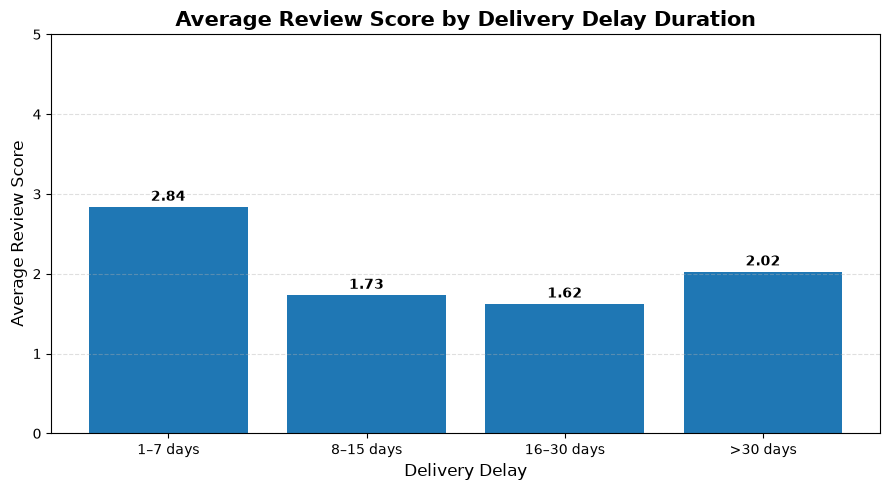

In [16]:
plt.figure(figsize=(9,5))

bars = plt.bar(
    delay_analysis['late_days'],
    delay_analysis['review_score']
)

plt.title(
    'Average Review Score by Delivery Delay Duration',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Delivery Delay', fontsize=12)
plt.ylabel('Average Review Score', fontsize=12)

plt.ylim(0,5)

plt.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.08,
        f'{height:.2f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )


# Save figure
plt.savefig(
    '../reports/delivery_delay_impact.png',
    dpi=300,
    bbox_inches='tight'
)

plt.tight_layout()
plt.show()

In [17]:
late_deliveries_by_state = (
    late_deliveries.groupby('customer_state')
    .agg(
        late_deliveries=('late_delivery_status', 'count'),
        avg_review_score=('review_score', 'mean'),
    )
    .reset_index()
)

display(late_deliveries_by_state.sort_values(by='late_deliveries', ascending=True))

,customer_state,late_deliveries,avg_review_score
3,AP,2,4.500000
0,AC,3,1.666667
2,AM,4,2.000000
21,RR,5,1.800000
20,RO,7,2.571429
26,TO,27,2.814815
19,RN,44,1.767442
24,SE,51,1.940000
12,MT,53,2.470588
14,PB,54,2.365385


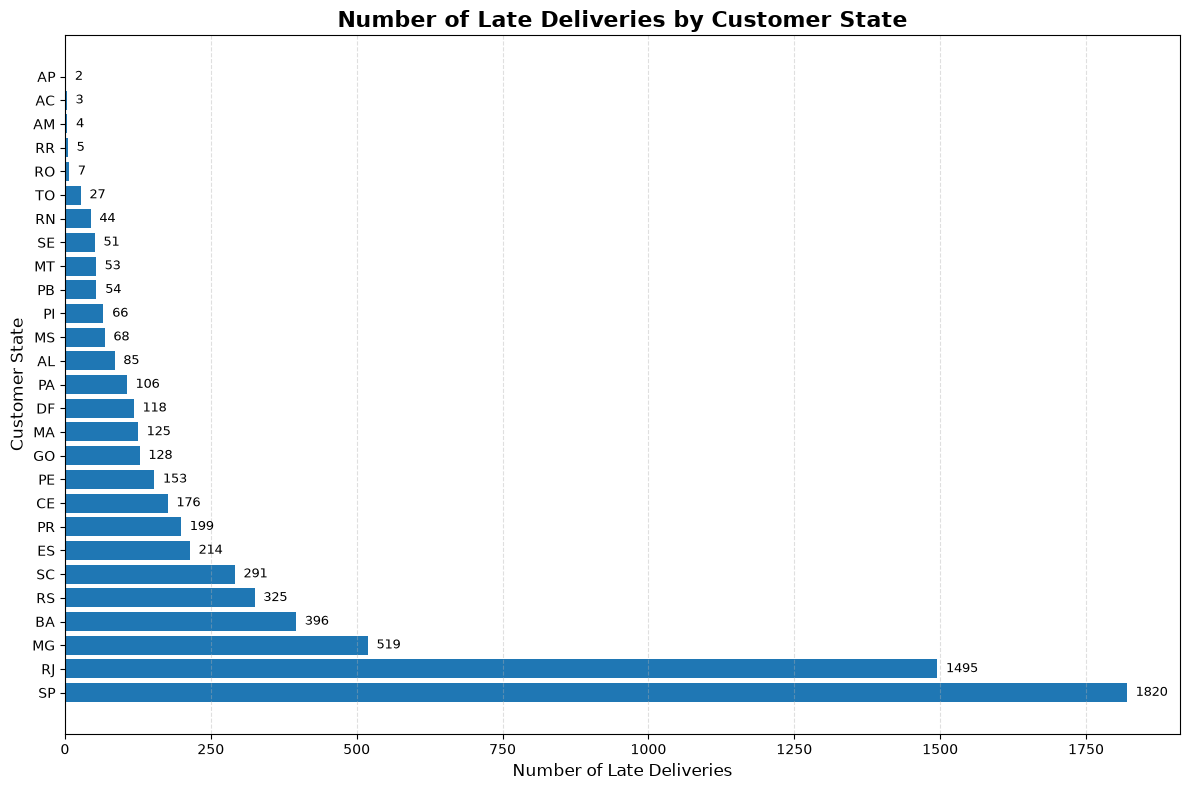

In [18]:
import matplotlib.pyplot as plt

# Sort by number of late deliveries (highest first)
state_delivery = late_deliveries_by_state.sort_values(
    by='late_deliveries',
    ascending=False
)

plt.figure(figsize=(12,8))

bars = plt.barh(
    state_delivery['customer_state'],
    state_delivery['late_deliveries']
)

plt.title(
    'Number of Late Deliveries by Customer State',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Number of Late Deliveries', fontsize=12)
plt.ylabel('Customer State', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.4)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 15,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        fontsize=9
    )

plt.tight_layout()

# Save figure
plt.savefig(
    '../reports/late_deliveries_by_state.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Executive Summary

### Business Objective

The objective of this analysis was to evaluate how delivery performance influences customer satisfaction by answering two key business questions:

1. Does late delivery negatively impact customer review scores?
2. Which states experience the highest concentration of late deliveries, and what insights can be derived from regional delivery performance?

---

### Key Findings

The analysis reveals a strong relationship between delivery timeliness and customer satisfaction. Customers whose orders were delivered on time awarded an average review score of **4.29**, whereas customers whose orders arrived late gave an average review score of only **2.27**. This difference of approximately **2 review points** on a five-point rating scale demonstrates that delivery punctuality is one of the most influential factors affecting the overall customer experience. From a business perspective, reducing late deliveries has the potential to significantly improve customer satisfaction and strengthen customer loyalty.

To further understand the severity of delivery delays, late orders were categorized according to the number of delayed days. The results indicate a clear downward trend in customer satisfaction as delays become longer. Deliveries delayed by **1–7 days** received the highest average review score among late orders (**2.83**), while delays between **8–15 days** and **16–30 days** experienced a substantial decline in customer ratings (**1.74** and **1.62**, respectively). These findings suggest that customer tolerance decreases rapidly once delivery delays extend beyond one week, emphasizing the importance of minimizing prolonged shipping delays.

An interesting exception was observed for deliveries delayed by **more than 30 days**, where the average review score increased to **2.02**. Although this result appears to contradict the overall trend, it should not be interpreted as evidence that extremely long delays improve customer satisfaction. Several business factors may explain this observation. Customers experiencing exceptionally long delays may have received refunds, discounts, replacement products, or proactive customer support, improving their perception of the overall shopping experience. In addition, some product categories—such as furniture, imported goods, or made-to-order items—naturally involve longer delivery expectations, making customers more accepting of extended waiting periods. Another possible explanation is that review scores reflect the entire shopping experience rather than delivery speed alone; customers may still provide relatively positive ratings if the product quality, seller communication, or issue resolution exceeded expectations. These hypotheses highlight the need for additional analysis incorporating product categories, seller performance, freight distance, and customer support interactions before drawing definitive conclusions.

The geographical analysis demonstrates that late deliveries are concentrated within a relatively small number of states. **São Paulo (SP)** recorded the highest number of late deliveries (**1,823**), followed by **Rio de Janeiro (RJ)** (**1,503**), **Minas Gerais (MG)** (**521**), **Bahia (BA)** (**400**), and **Rio Grande do Sul (RS)** (**329**). These states represent the largest operational burden and therefore offer the greatest opportunity for improving overall delivery performance. Because these regions also contain a large proportion of the customer base, even modest improvements in logistics efficiency could positively affect thousands of customer experiences.

Conversely, several states such as **Amapá (AP)**, **Acre (AC)**, **Amazonas (AM)**, and **Roraima (RR)** reported relatively few late deliveries. While AP exhibited the highest average review score among late deliveries, this result is based on only two delayed orders and therefore should not be considered representative of overall customer sentiment. Small sample sizes can produce unstable averages and should be interpreted cautiously.

---

### Business Insights

The findings suggest that delivery performance is a critical driver of customer satisfaction across the Olist platform. The sharp decline in review scores after the first week of delay indicates that customers become increasingly dissatisfied as promised delivery dates are missed. Therefore, preventing delays before they exceed one week should be considered a key operational objective.

The concentration of late deliveries in high-volume states such as São Paulo and Rio de Janeiro suggests that logistics improvements targeted toward these regions could generate the greatest business impact. Optimizing warehouse operations, improving carrier performance, or strengthening regional distribution networks in these states may substantially reduce the overall number of late deliveries.

Finally, the unexpected improvement in review scores for deliveries delayed beyond 30 days highlights the importance of investigating factors beyond logistics alone. Customer recovery strategies, compensation policies, product characteristics, and seller service quality may mitigate the negative effects of extreme delays. Understanding these relationships can help Olist design more effective customer service interventions while continuing to improve delivery performance.

---

### Conclusion

Overall, the analysis demonstrates a clear and consistent relationship between delivery timeliness and customer satisfaction. Customers strongly reward on-time deliveries with higher review scores, while longer delivery delays generally lead to progressively lower ratings. Although an improvement was observed for deliveries delayed by more than 30 days, this pattern is likely influenced by additional business factors rather than the delay itself and warrants further investigation.

From an operational perspective, reducing delivery delays—particularly in high-volume states such as São Paulo and Rio de Janeiro—represents one of the greatest opportunities for improving customer satisfaction and strengthening the overall customer experience on the Olist platform.